In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

In [ ]:
df = pd.read_csv("/Users/farahalmujaljel/Downloads/ksa_solar_dataset_2024_detailed.csv",encoding="latin1",engine="python")

In [ ]:
##Task 1 – Identify Data Quality Issues:
# preview dataset
df.head()

In [ ]:
##Task 1 – Identify Data Quality Issues:
# dataset structure
df.info()

In [ ]:
##Task 1 – Identify Data Quality Issues:
# check missing values
df.isnull().sum()

In [ ]:
##Task 1 – Identify Data Quality Issues:
# check duplicates
df.duplicated().sum()

In [ ]:
##Task 1 – Identify Data Quality Issues:
# summary
df.describe()

In [ ]:
##Task 1 – Identify Data Quality Issues:
# Visualization to detect outliers
df.boxplot(figsize=(10,6))
plt.show()

In [ ]:
##Task 2 – Handle Missing Values:
#  Fill missing values using mean Strategy
df = df.fillna(df.mean(numeric_only=True))

In [25]:
##Task 3 – Detect & Handle Outliers using IQR:
numeric_cols = df.select_dtypes(include=[np.number]).columns

#Define IQR
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Detect outliers
outliers = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) | 
            (df[numeric_cols] > (Q3 + 1.5 * IQR)))

# Count outliers in each column
print(outliers.sum())

# Remove rows containing outliers
df_clean = df[~outliers.any(axis=1)]

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Latitude                           0
Longitude                          0
Temperature (°C)                   0
Tilt (°)                           0
Panel Efficiency (%)               0
Solar Irradiance (kWh/m²/day)    186
Output Power (W)                   0
Estimated Daily Output (kWh)     276
dtype: int64
Original shape: (10980, 13)
Cleaned shape: (10704, 13)


In [26]:
##Task 3 – Detect & Handle Outliers using IQR:
# show outlier rows
outlier_rows = df[outliers.any(axis=1)]
outlier_rows.head()

,Date,City,Latitude,Longitude,Temperature (°C),Weather,Panel Type,Mount Type,Tilt (°),Panel Efficiency (%),Solar Irradiance (kWh/m²/day),Output Power (W),Estimated Daily Output (kWh)
8787,1/1/2024,Dammam,26.4207,50.0888,18,few clouds,Monocrystalline,Ground,15,22,4.42,1.56,17.45
8788,1/1/2024,Dammam,26.4207,50.0888,18,few clouds,Polycrystalline,Ground,15,18,4.42,1.27,17.45
8789,1/1/2024,Dammam,26.4207,50.0888,18,few clouds,Thin-Film,Ground,15,12,4.42,0.85,17.45
8793,1/2/2024,Dammam,26.4207,50.0888,18,few clouds,Monocrystalline,Ground,15,22,4.42,1.56,17.45
8794,1/2/2024,Dammam,26.4207,50.0888,18,few clouds,Polycrystalline,Ground,15,18,4.42,1.27,17.45


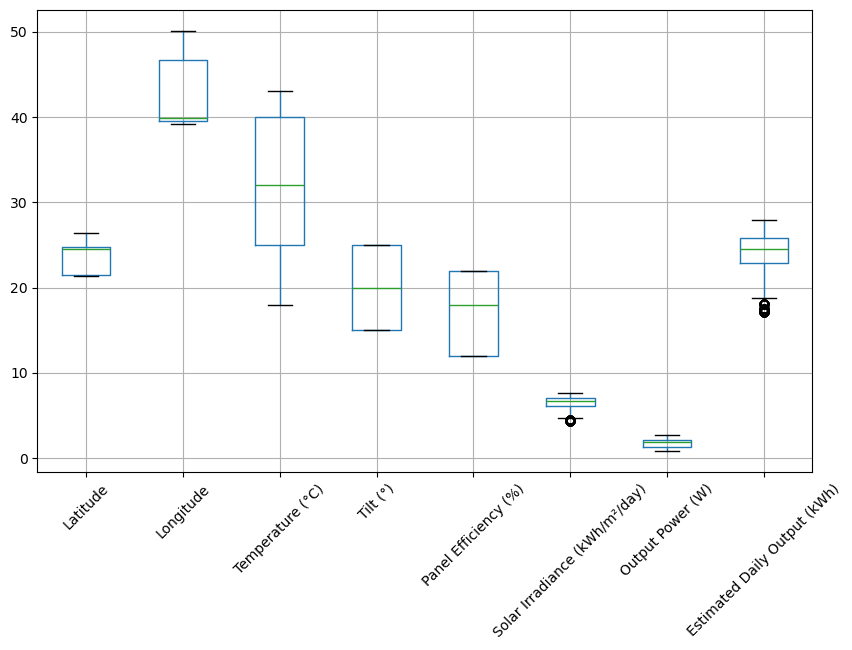

In [28]:
##Task 3 – Detect & Handle Outliers using IQR:
# show boxplot for numeric cols
df[numeric_cols].boxplot(figsize=(10,6))
plt.xticks(rotation=45)
plt.show()

In [29]:
##Task 4 – Normalize Features:
#Min-Max Normalization
minmax = MinMaxScaler()

df_minmax = df_clean.copy()
df_minmax[numeric_cols] = minmax.fit_transform(df_clean[numeric_cols])

df_minmax.head()

,Date,City,Latitude,Longitude,Temperature (°C),Weather,Panel Type,Mount Type,Tilt (°),Panel Efficiency (%),Solar Irradiance (kWh/m²/day),Output Power (W),Estimated Daily Output (kWh)
0,1/1/2024,Riyadh,0.660724,0.686729,0.0,few clouds,Monocrystalline,Rooftop,1.0,1.0,0.217082,0.560000,0.252723
1,1/1/2024,Riyadh,0.660724,0.686729,0.0,few clouds,Polycrystalline,Rooftop,1.0,0.6,0.217082,0.360000,0.252723
2,1/1/2024,Riyadh,0.660724,0.686729,0.0,few clouds,Thin-Film,Rooftop,1.0,0.0,0.217082,0.068571,0.252723
3,1/1/2024,Riyadh,0.660724,0.686729,0.0,few clouds,Monocrystalline,Ground,0.0,1.0,0.067616,0.474286,0.079521
4,1/1/2024,Riyadh,0.660724,0.686729,0.0,few clouds,Polycrystalline,Ground,0.0,0.6,0.067616,0.291429,0.079521


In [30]:
##Task 4 – Normalize Features:
#Z-score Normalization
scaler = StandardScaler()

df_zscore = df_clean.copy()
df_zscore[numeric_cols] = scaler.fit_transform(df_clean[numeric_cols])

df_zscore.head()

,Date,City,Latitude,Longitude,Temperature (°C),Weather,Panel Type,Mount Type,Tilt (°),Panel Efficiency (%),Solar Irradiance (kWh/m²/day),Output Power (W),Estimated Daily Output (kWh)
0,1/1/2024,Riyadh,0.554177,0.862777,-1.523811,few clouds,Monocrystalline,Rooftop,0.974539,1.135550,-1.734291,0.170073,-1.497079
1,1/1/2024,Riyadh,0.554177,0.862777,-1.523811,few clouds,Polycrystalline,Rooftop,0.974539,0.162221,-1.734291,-0.571124,-1.497079
2,1/1/2024,Riyadh,0.554177,0.862777,-1.523811,few clouds,Thin-Film,Rooftop,0.974539,-1.297771,-1.734291,-1.651154,-1.497079
3,1/1/2024,Riyadh,0.554177,0.862777,-1.523811,few clouds,Monocrystalline,Ground,-1.026126,1.135550,-2.356117,-0.147583,-2.252916
4,1/1/2024,Riyadh,0.554177,0.862777,-1.523811,few clouds,Polycrystalline,Ground,-1.026126,0.162221,-2.356117,-0.825249,-2.252916


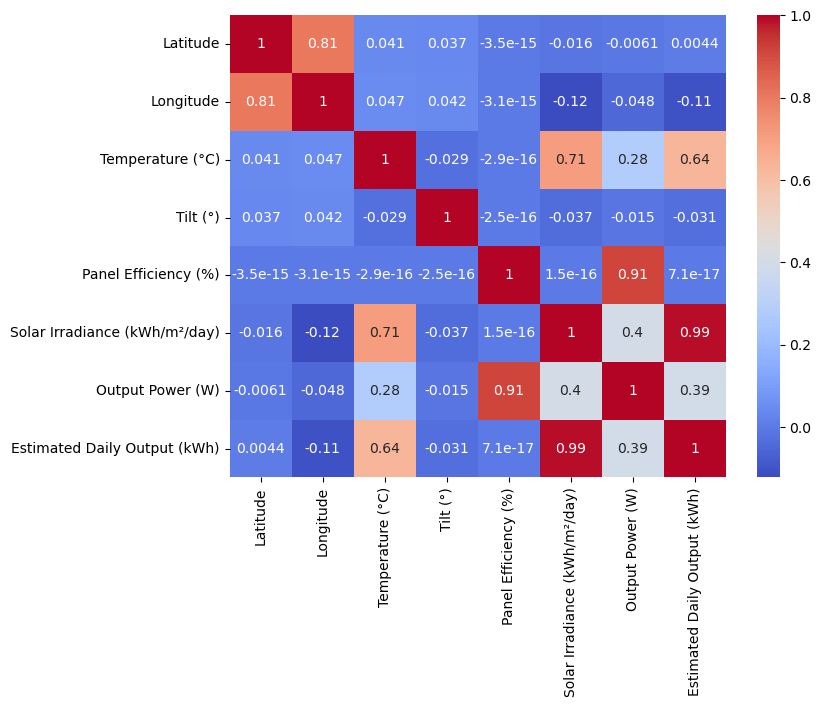

In [33]:
##Task 5 – Apply PCA:
#Check correlation(have to be <0.7)
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()

In [36]:
##Task 5 – Apply PCA:
#Apply PCA only on numerical columns
# Standardize first
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clean[numeric_cols])

# PCA
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_data)

df_pca = pd.DataFrame(pca_features, columns=['PC1', 'PC2'])
df_pca.head()

,PC1,PC2
0,-2.273428,0.997855
1,-2.759127,0.889186
2,-3.475037,0.728064
3,-3.081640,0.850542
4,-3.542061,0.745636


In [ ]:
# done by: fj:)